# VoD FMCW 하이브리드 위험도 파이프라인 — **최종 보고서 모드** (`23`)

`vod_full_report_main.FullReportNotebook`을 섹션별로 실행한다. **작업 디렉터리는 `vod-devkit`** 이어야 한다.

---


In [1]:
from pathlib import Path
import sys
NOTEBOOK_DIR = Path.cwd().resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))
from vod_full_report_main import FullReportNotebook
NB = FullReportNotebook(NOTEBOOK_DIR)


# Section 0. 목적과 전체 파이프라인

VoD FMCW 지상감지 레이더 포인트는 노이즈·다중경로·클래스 불균형으로 **raw point 분류**가 불안정하다. 본 노트북은 **후보 클러스터 생성 → 기하/시간/유틸리티 억제 → LiDAR corroboration → 트래킹 → 규칙 기반 위험 점수 → ML 보정 → hybrid 랭킹**까지 **Run All**로 재현 가능한 전 과정을 담는다.

**왜 랭킹인가**: 운영에서는 전 객체 검출보다 **상위 k개 위험 후보**에 자원을 집중하는 것이 현실적이다. **Honest evaluation**(프레임/시간/연속 블록 분할)은 누수를 줄이고 보고서의 신뢰도를 높인다.

> 구현 본문은 `vod_full_report_main.py`에 있으며, 아래 셀은 **동일 `NB` 인스턴스**에 섹션 메서드를 순서대로 호출한다.

# Section 1. 환경 설정

시드, 데이터 루트, 결과 경로, 선택적 부스터 패키지, ROI/클러스터/트래킹 파라미터를 고정한다.

In [2]:
NB.section1_environment()


HDBSCAN available: True


,key,value
0,NOTEBOOK_DIR,C:\Users\taehu\Desktop\projects\hanhwa_final\v...
1,DATASET_ROOT,C:\Users\taehu\Desktop\projects\hanhwa_final\v...
2,RADAR_MODE,5-scan
3,MAX_FRAMES,180
4,MAX_POINTS_PER_FRAME,2200
5,opt_hdbscan,True
6,opt_shap,False
7,opt_xgboost,False
8,opt_lightgbm,False
9,opt_catboost,False


# Section 2. 데이터 로딩 및 Raw EDA

레이더 포인트 cloud, 프레임 요약, LiDAR 포인트 수를 적재하고 RCS/속도/range 산점 등 **모델 입력 이전 분포**를 확인한다.

In [3]:
NB.section2_load_and_raw_eda()


[timed] section2_load_and_eda: 0.725s
radar_df shape: (175703, 11)


,frame_id,frame_order,radar_points_processed,lidar_points
0,00000,0,247,178104
1,00001,1,505,178500
2,00002,2,770,179092
3,00003,3,1039,179140
4,00004,4,1307,179550


,frame_id,frame_order,raw_points,processed_points,kept_ratio
0,00000,0,284,247,0.869718
1,00001,1,597,505,0.845896
2,00002,2,916,770,0.840611
3,00003,3,1242,1039,0.836554
4,00004,4,1590,1307,0.822013


,x,y,z,RCS,v_r,v_r_compensated,time,frame_id,frame_order,range_xy,abs_vr_comp
0,2.259143,-1.677923,-0.461345,-35.000000,-0.846359,0.003345,0.0,00000,0,2.814099,0.003345
1,2.892353,-1.702031,-0.484078,-35.000000,-0.945826,0.000521,0.0,00000,0,3.355982,0.000521
2,3.198316,-1.740433,-0.461826,-35.000000,-0.966848,0.008980,0.0,00000,0,3.641199,0.008980
3,5.296023,-1.029389,-0.228245,-21.281502,0.313759,1.494236,0.0,00000,0,5.395137,1.494236
4,4.892861,-1.705152,-0.610011,-31.324360,-1.089766,0.004509,0.0,00000,0,5.181470,0.004509


,count,mean,std,min,1%,10%,50%,90%,99%,max
x,175703.0,15.983723,11.847740,9.466823e-05,1.301708,3.633923,13.374722,31.994848,56.760800,69.993187
y,175703.0,-0.154490,7.879354,-3.499952e+01,-20.846053,-8.495228,-0.672569,8.886865,23.873991,34.993893
z,175703.0,0.124951,1.357401,-3.499551e+00,-2.959447,-1.330584,-0.116773,2.250831,3.751892,3.999733
RCS,175703.0,-12.368604,12.228426,-3.500000e+01,-35.000000,-29.210594,-12.427605,2.849743,20.241974,35.000000
v_r,175703.0,-1.348927,1.359421,-2.500000e+01,-3.378249,-2.302750,-1.564913,0.000000,1.655319,25.000000
v_r_compensated,175703.0,0.098715,1.219165,-2.480089e+01,-1.734941,-0.045923,0.000213,0.195696,3.763902,25.000000
range_xy,175703.0,17.563778,12.225785,8.306847e-02,1.901605,4.550952,14.670855,34.093372,58.514092,72.384438
abs_vr_comp,175703.0,0.286446,1.189141,1.815528e-07,0.000079,0.001003,0.007314,0.940383,3.885222,25.000000


### Raw point 통계 (요약)
**RCS**: mean=-12.37, median=-12.43, p10=-29.21, p90=2.85, std=12.23, nonzero_ratio=1.000
**v_r_compensated**: mean=0.09872, median=0.0002134, p10=-0.04592, p90=0.1957, std=1.219, nonzero_ratio=1.000
**range_xy**: mean=17.56, median=14.67, p10=4.551, p90=34.09, std=12.23, nonzero_ratio=1.000
**abs_vr_comp**: mean=0.2864, median=0.007314, p10=0.001003, p90=0.9404, std=1.189, nonzero_ratio=1.000
- **frame별 point 수**: mean=1107.3, median=1031.0
- **전처리 전/후 kept ratio**: mean frame kept_ratio=0.905



# Section 3. Radar 전처리

ROI 클리핑, RCS/속도 클립, 프레임당 포인트 상한으로 **신호 대 잡음**과 연산 부담을 동시에 제어한다.

[timed] section3_preprocess: 0.006s


,metric,value
0,n_raw_total,199319.000000
1,n_clean_total,175703.000000
2,keep_ratio_global,0.881517
3,keep_ratio_mean_frame,0.904775


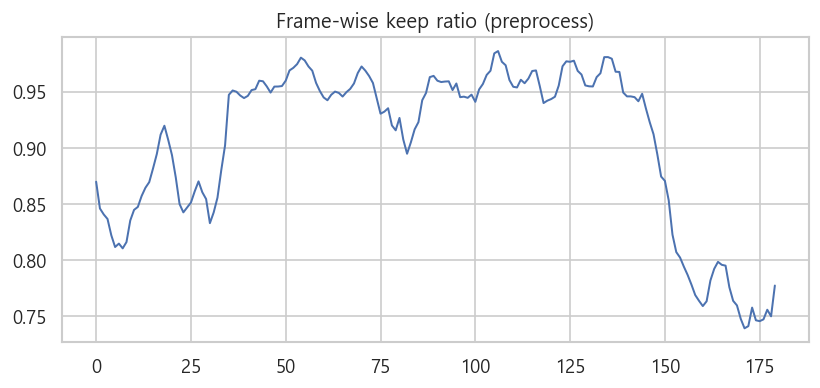

In [4]:
NB.section3_preprocess()


# Section 4. 후보 생성 (DBSCAN / HDBSCAN)

밀도 기반 클러스터링으로 **트랙 가능한 공간적 응집**을 후보 단위로 승격한다. 품질 점수로 알고리즘을 선택한다.

In [5]:
NB.section4_candidate_generation()


[timed] section4_candidate_generation: 18.556s


,algorithm,cluster_count,noise_ratio,mean_trackable_size_proxy,mean_spread_xy,mean_clusters_per_frame,quality_score
0,hdbscan,7561,0.224032,18.046951,0.741456,42.005556,0.975227
1,dbscan,2107,0.062720,78.592311,2.130424,11.705556,0.403371


# Section 5. 후보 억제 (S1/S2/S3)

기하 필터, 그리드 기반 시간적 희소성, 유틸리티 게이팅으로 **후보 폭발**을 억제한다. full / ops / ops_t* 부담을 비교한다.

In [6]:
NB.section5_suppression()


[timed] section5_suppression: 0.520s


,stage,n_candidates,remove_ratio,mode,topk_useful_keep_proxy
0,raw,7561,0.000000,full,0.00
1,S1_geometric,7561,0.000000,full,0.00
2,S2_temporal,7185,0.049729,full,0.00
3,S3_utility,6088,0.194816,full,0.00
4,raw,7561,0.000000,ops,0.02
5,S1_geometric,7561,0.000000,ops,0.02
6,S2_temporal,6629,0.123264,ops,0.02
7,S3_utility,4497,0.405237,ops,0.02
8,raw_ops_base,4497,0.000000,ops_t20,NaN
9,extra_gate_0.62,2370,0.472982,ops_t20,NaN


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,spread_xy,density_proxy,mean_rcs,rcs_std,mean_vr_comp,abs_vr_comp,vr_comp_std,z_std,time_mean
0,hdbscan,00000,0,0,hdbscan:00000:0,24,16.723734,-0.831550,1.150745,16.744394,3.772177,6.360688,-18.806913,4.500692,2.889690,2.889690,0.064849,1.453561,0.0
1,hdbscan,00000,0,1,hdbscan:00000:1,55,9.496860,-1.347430,-0.244307,9.591971,3.758439,14.629844,-14.177753,9.294411,1.510404,1.510404,0.163607,0.588353,0.0
2,hdbscan,00000,0,2,hdbscan:00000:2,39,15.058232,4.475281,-0.498472,15.709186,4.385626,8.890660,-9.939492,5.581155,-0.002348,0.024633,0.052935,1.163432,0.0
3,hdbscan,00000,0,3,hdbscan:00000:3,20,19.456871,14.164801,-0.908483,24.066811,4.539105,4.405184,-0.692822,6.937578,0.027917,0.059590,0.141815,0.799502,0.0
4,hdbscan,00000,0,4,hdbscan:00000:4,18,6.429248,-4.118162,-0.027550,7.635083,2.822962,6.374024,-15.506688,10.994450,0.005667,0.011893,0.029645,0.605183,0.0
5,hdbscan,00000,0,5,hdbscan:00000:5,19,29.275503,-12.447252,0.979113,31.811777,3.858086,4.923445,-1.417117,7.479192,-0.007359,0.009745,0.025614,1.742960,0.0
6,hdbscan,00000,0,6,hdbscan:00000:6,18,15.928190,-9.350979,-0.017205,18.470194,2.296128,7.835873,-3.115187,7.002433,-0.000879,0.002822,0.003501,1.068117,0.0
7,hdbscan,00001,1,0,hdbscan:00001:0,10,27.221777,2.605800,2.235157,27.346212,3.143944,3.179707,-19.246782,3.417619,2.807154,2.807154,0.057069,1.872108,-0.3


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,mean_rcs,rcs_std,mean_vr_comp,abs_vr_comp,vr_comp_std,z_std,time_mean,grid_count,proposal_quality_score,proposal_keep_flag
0,hdbscan,00001,1,3,hdbscan:00001:3,12,16.554157,-2.471586,1.079235,16.737648,...,-19.764748,3.086903,2.930000,2.930000,0.054726,1.654356,-0.666667,26,0.602563,1
1,hdbscan,00001,1,4,hdbscan:00001:4,20,14.337863,-0.270776,0.356462,14.340420,...,-20.625965,6.121262,2.925720,2.925720,0.028142,0.714524,-0.350000,27,0.645770,1
2,hdbscan,00002,2,2,hdbscan:00002:2,17,16.680450,-2.588163,0.981298,16.880049,...,-19.626081,3.012412,2.934572,2.934572,0.061582,1.804753,-1.294118,14,0.625286,1
3,hdbscan,00002,2,3,hdbscan:00002:3,10,15.440730,-0.266837,0.079750,15.443035,...,-21.699203,3.649882,2.928916,2.928916,0.018674,0.754895,-0.800000,8,0.639578,1
4,hdbscan,00002,2,4,hdbscan:00002:4,22,13.956811,-0.501093,0.451678,13.965803,...,-20.449224,6.787945,2.934850,2.934850,0.034915,0.663159,-0.863636,25,0.663115,1
5,hdbscan,00002,2,5,hdbscan:00002:5,13,30.398338,-10.043882,-1.710209,32.014660,...,-11.572770,3.039805,-0.849708,0.849708,0.105203,0.745917,-0.923077,2,0.620992,1
6,hdbscan,00002,2,7,hdbscan:00002:7,10,11.474182,-2.489938,-0.008923,11.741237,...,-19.617413,5.411063,1.828978,1.828978,0.062713,0.228481,-0.900000,28,0.616564,1
7,hdbscan,00002,2,11,hdbscan:00002:11,17,5.994259,-0.938920,-0.091296,6.067348,...,-5.014764,8.930916,1.511395,1.511395,0.012196,0.175518,-1.176471,27,0.653171,1


,count,mean,std,min,10%,50%,90%,max
n_points,4497.0,20.487214,21.100049,8.000000,9.000000,15.000000,33.000000,226.000000
spread_xy,4497.0,0.415250,0.389076,0.020110,0.090748,0.296922,0.878823,4.270748
mean_rcs,4497.0,-11.203279,9.087137,-35.000000,-22.268385,-11.192487,0.264247,14.993655
mean_vr_comp,4497.0,0.061924,0.516953,-1.997448,-0.011206,0.000931,0.008093,4.146639
vr_comp_std,4497.0,0.020918,0.047288,0.000270,0.003087,0.007391,0.040734,0.538954
density_proxy,4497.0,68.085148,51.033209,11.887269,29.168385,52.864331,123.275254,489.826448
proposal_quality_score,4497.0,0.671992,0.061439,0.595162,0.606371,0.655142,0.776651,0.864114


# Section 6. LiDAR corroboration + 듀얼 파이프라인

`run_branch`가 LiDAR v3 점수, baseline/improved 트래킹, 규칙 점수, ML, 보정, hybrid, 랭킹, ablation까지 일괄 수행한다.

In [7]:
NB.section6_dual_pipeline()


[timed] section6_dual_pipeline: 610.943s
=== full suppressed 6088 tracked 6088
=== ops suppressed 4497 tracked 4497
=== ops_t20 suppressed 2370 tracked 2370
=== ops_t18 suppressed 2064 tracked 2064
=== ops_t15 suppressed 1758 tracked 1758


# Section 7. Tracking 및 temporal feature

프래그멘테이션, 평균 트랙 길이, approach / consistency 분포를 요약한다.

In [8]:
NB.section7_tracking_and_temporal()


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio,pipeline_mode
0,baseline,528,11.530303,0.176136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,full
1,improved,470,12.953191,0.114894,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,full


,count,mean,std,min,10%,50%,90%,max
track_len,6088.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
approach_score,6088.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,feature,mean,std,median,p90,nonzero_ratio
0,approach_score,0.0,0.0,0.0,0.0,0.0
1,temporal_stability_score,0.0,0.0,0.0,0.0,0.0


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio,pipeline_mode
0,baseline,435,10.337931,0.211494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ops
1,improved,355,12.667606,0.098592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ops


,count,mean,std,min,10%,50%,90%,max
track_len,4497.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
approach_score,4497.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,feature,mean,std,median,p90,nonzero_ratio
0,approach_score,0.0,0.0,0.0,0.0,0.0
1,temporal_stability_score,0.0,0.0,0.0,0.0,0.0


# Section 8. Rule-based risk scoring

rule v1/v2 및 threshold sensitivity 표를 확인한다.

In [9]:
NB.section8_rule_scores()


,risk_score_rule_v1,risk_score_rule_v2
count,6088.000000,6088.000000
mean,0.169254,0.262134
std,0.054094,0.049000
min,0.002677,0.052536
25%,0.139882,0.238112
50%,0.174881,0.269055
75%,0.199670,0.295389
max,0.457842,0.429151


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,6071,17,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,5215,730,143,1.0,0.0,3.964491,0.562154
2,quantile_only_q0.92,4992,609,487,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,5114,608,366,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,5235,609,244,NaN,NaN,NaN,NaN


,risk_score_rule_v1,risk_score_rule_v2
count,4497.000000,4497.000000
mean,0.177315,0.269551
std,0.050374,0.043802
min,0.006635,0.088354
25%,0.152465,0.248981
50%,0.179903,0.274306
75%,0.203421,0.297635
max,0.453302,0.408252


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,4486,11,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,3852,539,106,1.0,0.0,3.729895,0.566554
2,quantile_only_q0.92,3687,450,360,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,3777,450,270,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,3867,450,180,NaN,NaN,NaN,NaN


# Section 9. Feature set & anti-leakage

블랙리스트(`ttc`,`range_xy`,`abs_vr_comp`) 및 rule/hybrid 라벨·점수 컬럼이 **A/B feature set**에 섞이면 즉시 중단(assert)한다.

In [10]:
NB.section9_anti_leakage()


,feature_set,blacklist_hits,passed
0,A_strict_anti_leakage,,True
1,B_moderate_anti_leakage,,True


,feature_set,n_features,contains_leakage_core,contains_ttc,contains_range_xy,contains_abs_vr_comp,contains_rule_score_like_feature,anti_leakage_passed,sample_features
0,A_strict_anti_leakage,31,False,False,False,False,False,True,"spread_xy, density_proxy, n_points, mean_rcs, ..."
1,B_moderate_anti_leakage,37,False,False,False,False,False,True,"spread_xy, density_proxy, n_points, mean_rcs, ..."
2,C_diagnostic_leakage,39,True,False,False,False,True,False,"spread_xy, density_proxy, n_points, mean_rcs, ..."


# Section 10. Split 설계

group_frame / time / contiguous_block / **random**(overall 진단용) 요약.

In [11]:
NB.section10_splits()


,split,n_train,n_test,train_high,test_high
0,random,3373,1124,81,25
1,group_frame,3398,1099,85,21
2,time,3361,1136,82,24
3,contiguous_block,2986,1511,76,30


# Section 11. ML refinement

`best_model_summary_overall`(random 포함 가능)과 **`best_model_summary_honest`**를 분리한다. **최종 발표는 honest만** 사용한다.

In [12]:
NB.section11_ml()


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2
0,classification,logreg,A_strict_anti_leakage,random,0.905536,0.720930,0.575441,1.0,0.185393,-0.098017,NaN,NaN
1,classification,rf,A_strict_anti_leakage,random,0.940042,0.790698,0.593335,1.0,0.191011,0.059958,NaN,NaN
2,classification,svm_rbf,A_strict_anti_leakage,random,0.905536,0.720930,0.496849,1.0,0.185393,0.036533,NaN,NaN
3,classification,hgb,A_strict_anti_leakage,random,0.962402,0.883721,0.659677,1.0,0.219101,0.037598,NaN,NaN
4,regression,rf_reg,A_strict_anti_leakage,random,NaN,NaN,0.949627,NaN,NaN,NaN,0.005560,0.967858
5,regression,hgb_reg,A_strict_anti_leakage,random,NaN,NaN,0.912242,NaN,NaN,NaN,0.005311,0.973925
6,classification,logreg,A_strict_anti_leakage,group_frame,0.917697,0.787879,0.529878,1.0,0.644444,-0.097206,NaN,NaN
7,classification,rf,A_strict_anti_leakage,group_frame,0.967079,0.878788,0.553846,1.0,0.644444,0.032921,NaN,NaN
8,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.950618,0.848485,0.472348,1.0,0.644444,-0.003018,NaN,NaN
9,classification,hgb,A_strict_anti_leakage,group_frame,0.984043,0.939394,0.587849,1.0,0.688889,0.015957,NaN,NaN


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,score,scope,mode
27,classification,hgb,B_moderate_anti_leakage,random,0.981846,0.953488,0.846852,1.0,0.235955,0.018154,NaN,NaN,0.944922,overall_any_split,full


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,score,scope,mode
33,classification,hgb,B_moderate_anti_leakage,group_frame,0.984043,0.939394,0.81905,1.0,0.688889,0.015957,NaN,NaN,0.935417,honest_only,full


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2
0,classification,logreg,A_strict_anti_leakage,random,0.844647,0.640000,0.545377,0.8,0.117978,-0.038272,NaN,NaN
1,classification,rf,A_strict_anti_leakage,random,0.902949,0.680000,0.503283,1.0,0.095506,0.097051,NaN,NaN
2,classification,svm_rbf,A_strict_anti_leakage,random,0.957424,0.880000,0.514808,1.0,0.129213,0.008923,NaN,NaN
3,classification,hgb,A_strict_anti_leakage,random,0.943310,0.800000,0.567416,1.0,0.112360,0.056690,NaN,NaN
4,regression,rf_reg,A_strict_anti_leakage,random,NaN,NaN,0.925476,NaN,NaN,NaN,0.004743,0.961951
5,regression,hgb_reg,A_strict_anti_leakage,random,NaN,NaN,0.907922,NaN,NaN,NaN,0.004900,0.965900
6,classification,logreg,A_strict_anti_leakage,group_frame,0.923610,0.809524,0.527063,1.0,0.422222,-0.162484,NaN,NaN
7,classification,rf,A_strict_anti_leakage,group_frame,0.974537,0.904762,0.411484,1.0,0.422222,0.025463,NaN,NaN
8,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.975727,0.952381,0.435269,1.0,0.466667,-0.007730,NaN,NaN
9,classification,hgb,A_strict_anti_leakage,group_frame,0.987573,0.952381,0.453802,1.0,0.444444,0.012427,NaN,NaN


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,score,scope,mode
30,classification,logreg,B_moderate_anti_leakage,group_frame,1.0,1.0,0.750812,1.0,0.466667,-0.01831,NaN,NaN,0.950162,overall_any_split,ops


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,score,scope,mode
30,classification,logreg,B_moderate_anti_leakage,group_frame,1.0,1.0,0.750812,1.0,0.466667,-0.01831,NaN,NaN,0.950162,honest_only,ops


,pipeline_mode,model,feature_set,split,macro_f1,high_recall,ranking_ap
0,full,hgb,B_moderate_anti_leakage,random,0.981846,0.953488,0.846852
1,ops,logreg,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.750812
2,ops_t20,logreg,B_moderate_anti_leakage,group_frame,0.953744,0.833333,0.828397
3,ops_t18,logreg,B_moderate_anti_leakage,group_frame,0.975733,0.909091,0.684777
4,ops_t15,hgb,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.551982


,pipeline_mode,model,feature_set,split,macro_f1,high_recall,ranking_ap
0,full,hgb,B_moderate_anti_leakage,group_frame,0.984043,0.939394,0.819050
1,ops,logreg,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.750812
2,ops_t20,logreg,B_moderate_anti_leakage,group_frame,0.953744,0.833333,0.828397
3,ops_t18,logreg,B_moderate_anti_leakage,group_frame,0.975733,0.909091,0.684777
4,ops_t15,hgb,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.551982


# Section 12. Calibration

raw vs Platt vs isotonic(Brier/ECE/랭킹/포화). **raw보다 Brier·ECE가 나빠지면 채택하지 않는다.**

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.001428,0.001747,0.477405,1.0,0.018843,0.017544,0.977258
1,platt_cv,0.001703,0.006008,0.814324,1.0,0.010396,0.000650,0.001949
2,isotonic_cv,0.001758,0.004448,0.655248,1.0,0.016244,0.016244,0.898635


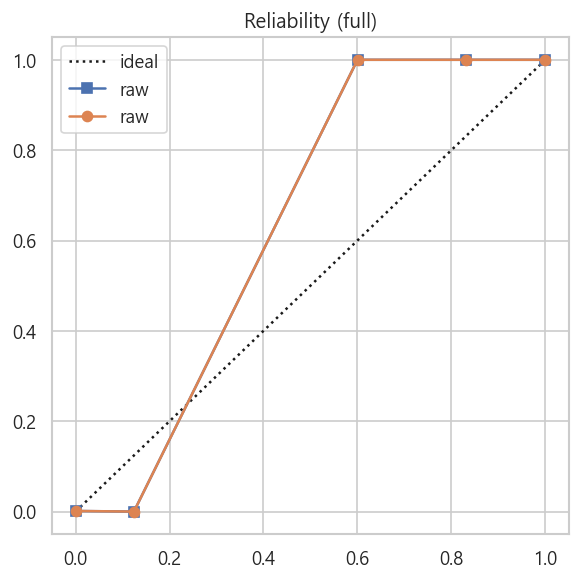

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.000151,0.001274,0.750812,1.0,0.011829,0.007279,0.924477
1,platt_cv,0.000641,0.005308,0.668783,1.0,0.006369,0.002730,0.479527
2,isotonic_cv,0.000740,0.003823,0.439082,1.0,0.008189,0.008189,0.941765


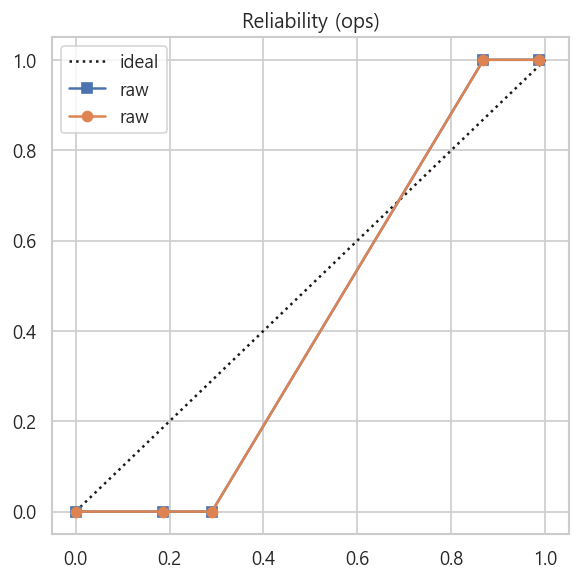

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.002337,0.008280,0.828397,1.0,0.009449,0.007874,0.784252
1,platt_cv,0.005025,0.015505,0.757807,1.0,0.000000,0.000000,0.026772
2,isotonic_cv,0.004166,0.014115,0.738482,1.0,0.009449,0.009449,0.667717


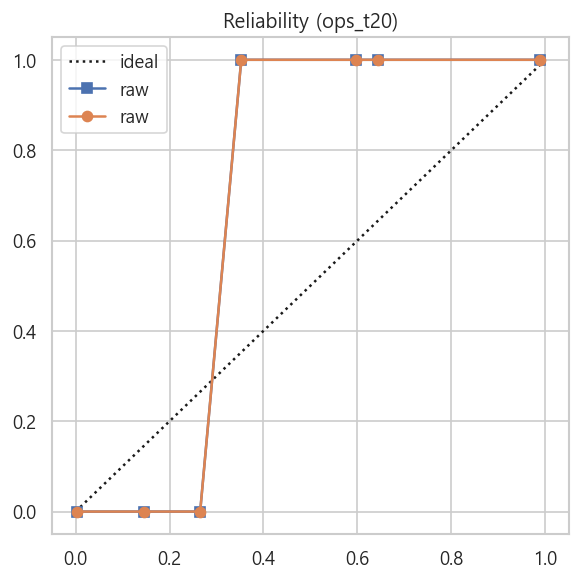

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.002696,0.003763,0.684777,1.0,0.008977,0.003591,0.833034
1,platt_cv,0.005041,0.013338,0.641716,1.0,0.000000,0.000000,0.039497
2,isotonic_cv,0.004070,0.008633,0.491601,1.0,0.005386,0.005386,0.877917


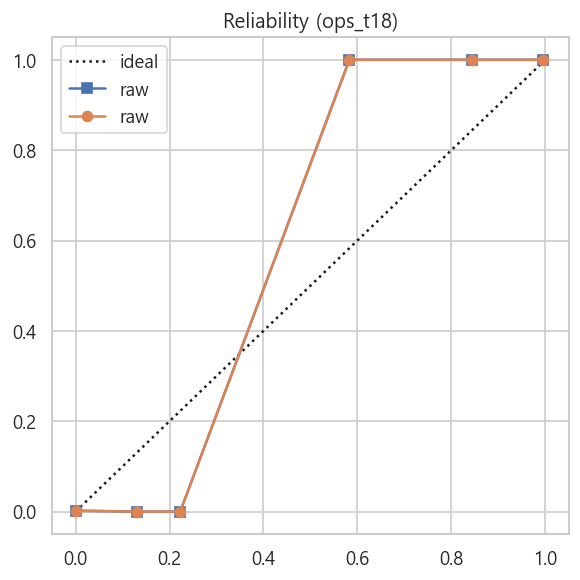

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,1.221058e-08,0.000007,0.379593,0.4,0.008584,0.008584,0.989270
1,platt_cv,5.016780e-04,0.006183,0.560218,0.4,0.000000,0.000000,0.000000
2,isotonic_cv,5.247066e-04,0.001796,0.234773,0.4,0.008584,0.008584,0.984979


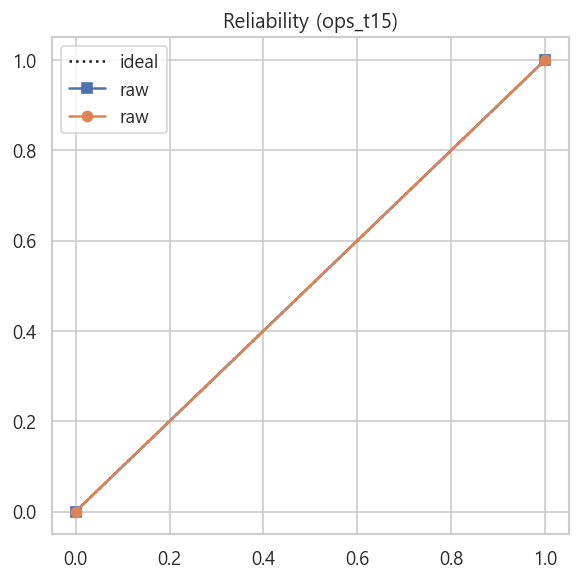

In [13]:
NB.section12_calibration()


# Section 13. Hybrid score

rule vs hybrid overlap, 가중치 sweep, 부담-정밀 trade-off.

In [14]:
NB.section13_hybrid()


,topk,overlap,rule_only_mean_score,hybrid_mean_score,mode
0,30,0.4,0.262134,0.35082,full


,W_LIDAR,W_TEMPORAL,W_RELIABILITY,W_QUALITY,W_UNCERTAINTY,ranking_ap,p10,burden_per_frame,mode
0,0.10,0.10,0.08,0.06,0.18,0.672588,1.0,33.822222,full
1,0.12,0.10,0.10,0.08,0.20,0.671561,1.0,33.822222,full
2,0.08,0.14,0.10,0.08,0.22,0.558312,1.0,33.822222,full


,topk,overlap,rule_only_mean_score,hybrid_mean_score,mode
0,30,0.633333,0.269551,0.361183,ops


,W_LIDAR,W_TEMPORAL,W_RELIABILITY,W_QUALITY,W_UNCERTAINTY,ranking_ap,p10,burden_per_frame,mode
0,0.10,0.10,0.08,0.06,0.18,0.629400,1.0,25.122905,ops
1,0.12,0.10,0.10,0.08,0.20,0.627540,1.0,25.122905,ops
2,0.08,0.14,0.10,0.08,0.22,0.498708,1.0,25.122905,ops


# Section 14. Ranking evaluation

precision@k, AP/MAP/NDCG/MRR, Spearman/Kendall, burden proxy.

In [15]:
NB.section14_ranking()


,metric,value,mode
0,precision@5_hard,1.000000,full
1,precision@10_hard,1.000000,full
2,recall@10_hard,0.069930,full
3,ap_soft,0.671561,full
4,map,0.671561,full
5,mrr,1.000000,full
6,ndcg@10,1.000000,full
7,track_ap,0.741134,full
8,window10_hit_rate,0.722222,full
9,window20_hit_rate,0.777778,full


,metric,value,mode
0,precision@5_hard,1.000000,ops
1,precision@10_hard,1.000000,ops
2,recall@10_hard,0.094340,ops
3,ap_soft,0.627540,ops
4,map,0.627540,ops
5,mrr,1.000000,ops
6,ndcg@10,1.000000,ops
7,track_ap,0.854661,ops
8,window10_hit_rate,0.555556,ops
9,window20_hit_rate,0.666667,ops


# Section 15. Ablation

full_model, no_lidar, no_tracking_features, no_calibration, rule_only, ml_only, rule_plus_ml_hybrid.

**rule_only가 강할 수 있음**을 숨기지 않는다. hybrid는 부담·불확실성·설명·운영 포인트 측면에서 평가한다.

In [16]:
NB.section15_ablation()


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,mode
0,full_model,0.637409,0.839161,0.671561,1.0,2.033333,full
1,rule_only,0.703361,1.000000,1.000000,1.0,2.033333,full
2,no_lidar,0.631639,0.825175,0.650869,1.0,2.033333,full
3,no_tracking_features,0.685119,0.909091,0.787865,1.0,2.033333,full
4,no_calibration,0.680864,0.916084,0.804568,1.0,2.033333,full
5,ml_only,0.015300,1.000000,0.142888,1.0,33.822222,full
6,rule_plus_ml_hybrid,0.643776,0.951049,0.766925,1.0,2.033333,full


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,mode
0,full_model,0.659164,0.971698,0.627540,1.0,1.508380,ops
1,rule_only,0.704220,1.000000,1.000000,1.0,1.508380,ops
2,no_lidar,0.646483,0.952830,0.597490,1.0,1.508380,ops
3,no_tracking_features,0.708929,1.000000,0.758543,1.0,1.508380,ops
4,no_calibration,0.685505,0.981132,0.814515,1.0,1.508380,ops
5,ml_only,0.015352,1.000000,0.134064,1.0,25.122905,ops
6,rule_plus_ml_hybrid,0.661585,1.000000,0.829236,1.0,1.508380,ops


# Section 16. Runtime

단계별 wall-clock 요약.

In [17]:
NB.section16_runtime()


,stage,sec
0,section2_load_and_eda,0.725320
1,section3_preprocess,0.005703
2,section4_candidate_generation,18.556120
3,section5_suppression,0.520496
4,section6_dual_pipeline,610.942984


# Section 17. Explainability

top-k 후보 및 hard case 테이블 CSV 저장.

In [18]:
NB.section17_explainability()


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00118:0,234,0.629734,high,0.882413,0.261303,33,0.0,0.712092,0.607895,"근접성:0.89, LiDAR 정합:0.61, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.442, 보정신뢰=0.882, 불확실성=0.261."
1,hdbscan:00117:0,234,0.616541,high,0.881309,0.263755,33,0.0,0.712092,0.561219,"근접성:0.88, LiDAR 정합:0.56, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.434, 보정신뢰=0.881, 불확실성=0.264."
2,hdbscan:00113:2,234,0.613644,high,0.880629,0.265266,33,0.0,0.712092,0.511728,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.422, 보정신뢰=0.881, 불확실성=0.265."
3,hdbscan:00109:2,234,0.607080,high,0.880038,0.266568,33,0.0,0.712092,0.521178,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.48",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.404, 보정신뢰=0.880, 불확실성=0.267."
4,hdbscan:00096:5,234,0.606376,high,0.879811,0.267086,33,0.0,0.712092,0.528962,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.406, 보정신뢰=0.880, 불확실성=0.267."
5,hdbscan:00097:6,234,0.605160,high,0.879687,0.267360,33,0.0,0.712092,0.527624,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.401, 보정신뢰=0.880, 불확실성=0.267."
6,hdbscan:00093:3,234,0.602352,high,0.879384,0.268034,33,0.0,0.712092,0.529643,"근접성:0.87, LiDAR 정합:0.53, 운동 이상:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.406, 보정신뢰=0.879, 불확실성=0.268."
7,hdbscan:00120:0,234,0.594182,high,0.879731,0.267263,33,0.0,0.712092,0.497488,"근접성:0.88, LiDAR 정합:0.50, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.427, 보정신뢰=0.880, 불확실성=0.267."
8,hdbscan:00100:20,248,0.577861,high,0.882942,0.260125,11,0.0,0.817537,0.478159,"근접성:0.90, LiDAR 정합:0.48, 운동 이상:0.34",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.376, 보정신뢰=0.883, 불확실성=0.260."
9,hdbscan:00012:4,1,0.568508,high,0.875749,0.276109,36,0.0,0.658020,0.610494,"근접성:0.80, LiDAR 정합:0.61, 운동 이상:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.341, 보정신뢰=0.876, 불확실성=0.276."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4,hard_tmp,case_type
0,hdbscan,00001,1,10,hdbscan:00001:10,23,6.030051,-4.650162,-0.132717,7.614822,...,0.0,0.314178,0.062549,0.044286,0.031418,0.045499,0.1,0.397930,0,medium_but_persistent
1,hdbscan,00002,2,19,hdbscan:00002:19,17,4.506492,-4.437491,-0.154063,6.324539,...,0.0,0.316943,0.060703,0.032810,0.031694,0.048483,0.1,0.390633,0,medium_but_persistent
2,hdbscan,00003,3,2,hdbscan:00003:2,9,11.409592,1.454494,-0.182172,11.501927,...,0.0,0.331580,0.054172,0.021301,0.033158,0.049092,0.1,0.389303,0,medium_but_persistent
3,hdbscan,00003,3,19,hdbscan:00003:19,16,3.790225,-1.932908,-0.476325,4.254637,...,0.0,0.330268,0.062686,0.048492,0.033027,0.046051,0.1,0.420523,0,medium_but_persistent
4,hdbscan,00003,3,29,hdbscan:00003:29,20,4.449681,-4.491398,-0.166724,6.322367,...,0.0,0.316651,0.060502,0.032810,0.031665,0.050560,0.1,0.392187,0,medium_but_persistent
5,hdbscan,00003,3,31,hdbscan:00003:31,12,8.300339,-0.685513,-0.321639,8.328598,...,0.0,0.320857,0.065456,0.063110,0.032086,0.053911,0.1,0.435419,0,medium_but_persistent
6,hdbscan,00003,3,33,hdbscan:00003:33,36,6.613649,0.018519,-0.463448,6.613675,...,0.0,0.320242,0.059233,0.077660,0.032024,0.060745,0.1,0.449905,0,medium_but_persistent
7,hdbscan,00004,4,24,hdbscan:00004:24,14,8.038463,-2.448786,0.041961,8.403180,...,0.0,0.332223,0.057365,0.019744,0.033222,0.051968,0.1,0.394522,0,medium_but_persistent
8,hdbscan,00004,4,25,hdbscan:00004:25,11,9.316492,-2.895012,-0.473972,9.755927,...,0.0,0.313378,0.056458,0.032764,0.031338,0.054344,0.1,0.388282,0,medium_but_persistent
9,hdbscan,00004,4,28,hdbscan:00004:28,21,3.723038,-2.020706,-0.493190,4.236067,...,0.0,0.329884,0.062423,0.048492,0.032988,0.048995,0.1,0.422782,0,medium_but_persistent


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00116:0,172,0.615423,high,0.886840,0.251464,30,0.0,0.868005,0.555245,"근접성:0.89, LiDAR 정합:0.56, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.423, 보정신뢰=0.887, 불확실성=0.251."
1,hdbscan:00115:0,172,0.615273,high,0.886613,0.251969,30,0.0,0.868005,0.540991,"근접성:0.89, LiDAR 정합:0.54, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.420, 보정신뢰=0.887, 불확실성=0.252."
2,hdbscan:00112:2,172,0.612751,high,0.886089,0.253119,30,0.0,0.868005,0.509262,"근접성:0.89, LiDAR 정합:0.51, 접근/시간여유:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.410, 보정신뢰=0.886, 불확실성=0.253."
3,hdbscan:00114:2,172,0.611242,high,0.886086,0.253139,30,0.0,0.868005,0.519083,"근접성:0.89, LiDAR 정합:0.52, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.416, 보정신뢰=0.886, 불확실성=0.253."
4,hdbscan:00096:5,172,0.605599,high,0.885374,0.254679,30,0.0,0.868005,0.528962,"근접성:0.89, LiDAR 정합:0.53, 접근/시간여유:0.37",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.397, 보정신뢰=0.885, 불확실성=0.255."
5,hdbscan:00094:3,172,0.604534,high,0.885026,0.255467,30,0.0,0.868005,0.514613,"근접성:0.88, LiDAR 정합:0.51, 접근/시간여유:0.39",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.398, 보정신뢰=0.885, 불확실성=0.255."
6,hdbscan:00120:0,172,0.593608,high,0.885371,0.254728,30,0.0,0.868005,0.497488,"근접성:0.88, LiDAR 정합:0.50, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.418, 보정신뢰=0.885, 불확실성=0.255."
7,hdbscan:00099:6,172,0.586808,high,0.880241,0.263693,30,0.0,0.868005,0.488215,"근접성:0.90, LiDAR 정합:0.49, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.370, 보정신뢰=0.880, 불확실성=0.264."
8,hdbscan:00013:2,22,0.565420,high,0.874832,0.275704,29,0.0,0.724478,0.607697,"근접성:0.80, LiDAR 정합:0.61, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.337, 보정신뢰=0.875, 불확실성=0.276."
9,hdbscan:00010:8,22,0.558370,high,0.867594,0.286130,29,0.0,0.724478,0.616255,"근접성:0.79, LiDAR 정합:0.62, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.332, 보정신뢰=0.868, 불확실성=0.286."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4,hard_tmp,case_type
0,hdbscan,00003,3,2,hdbscan:00003:2,9,11.409592,1.454494,-0.182172,11.501927,...,0.0,0.331580,0.054172,0.034868,0.033158,0.048987,0.1,0.402765,0,medium_but_persistent
1,hdbscan,00004,4,2,hdbscan:00004:2,9,11.311281,1.267381,-0.180891,11.382062,...,0.0,0.332750,0.054220,0.034868,0.033275,0.048987,0.1,0.404100,0,medium_but_persistent
2,hdbscan,00004,4,24,hdbscan:00004:24,14,8.038463,-2.448786,0.041961,8.403180,...,0.0,0.332223,0.057365,0.053792,0.033222,0.051794,0.1,0.428396,0,medium_but_persistent
3,hdbscan,00004,4,28,hdbscan:00004:28,21,3.723038,-2.020706,-0.493190,4.236067,...,0.0,0.329884,0.062423,0.025539,0.032988,0.048858,0.1,0.399692,0,medium_but_persistent
4,hdbscan,00005,5,20,hdbscan:00005:20,25,3.489276,-1.883031,-0.541588,3.964953,...,0.0,0.330203,0.062086,0.025539,0.033020,0.050091,0.1,0.400939,0,medium_but_persistent
5,hdbscan,00005,5,35,hdbscan:00005:35,13,8.033880,-2.609080,0.053654,8.446924,...,0.0,0.331730,0.057353,0.053792,0.033173,0.050609,0.1,0.426656,0,medium_but_persistent
6,hdbscan,00006,6,11,hdbscan:00006:11,27,3.357191,-1.791310,-0.509389,3.805197,...,0.0,0.331450,0.062379,0.025539,0.033145,0.048958,0.1,0.401471,0,medium_but_persistent
7,hdbscan,00007,7,30,hdbscan:00007:30,42,8.465387,-3.175342,-0.182881,9.041327,...,0.0,0.322915,0.062872,0.049804,0.032291,0.051384,0.1,0.419267,0,medium_but_persistent
8,hdbscan,00008,8,13,hdbscan:00008:13,11,7.651906,-0.904183,-0.924065,7.705142,...,0.0,0.321483,0.064575,0.025539,0.032148,0.047914,0.1,0.391659,0,medium_but_persistent
9,hdbscan,00008,8,21,hdbscan:00008:21,27,3.181148,-2.226798,-0.519525,3.883082,...,0.0,0.331510,0.062687,0.033017,0.033151,0.050522,0.1,0.410887,0,medium_but_persistent


# Section 18. Temporal effectiveness

permutation importance 기반 temporal 기여 요약.

In [19]:
NB.section18_temporal_effectiveness()


,temporal_feature_importance_sum,n_temporal_cols_used,mode
0,0.000164,15,full


,temporal_feature_importance_sum,n_temporal_cols_used,mode
0,0.0,15,ops


# Section 19. Final summary & source trace

`research_full` vs `ops_low_burden` 요약, **honest 실험 row와 summary 수치 일치 assert**.

In [20]:
NB.section19_final_summary()


,summary_scope,pipeline_mode,selected_clusterer,selected_tracking_mode,honest_best_model,honest_eval_split,honest_feature_set,macro_f1,high_recall,ranking_ap,burden_per_frame,runtime_sec_total,calibration_used,selected_calibration_method,brier_raw,brier_selected,ece_raw,ece_selected
0,research_full,full,hdbscan,improved,hgb,group_frame,B_moderate_anti_leakage,0.984043,0.939394,0.671561,33.822222,630.750622,False,raw,0.001428,0.001428,0.001747,0.001747
1,ops_low_burden,ops,hdbscan,improved,logreg,group_frame,B_moderate_anti_leakage,1.000000,1.000000,0.627540,25.122905,630.750622,False,raw,0.000151,0.000151,0.001274,0.001274


,pipeline_mode,source_macro_f1,source_high_recall,source_test_n,source_test_high_n,summary_macro_f1,summary_high_recall
0,full,0.984043,0.939394,1539,33,0.984043,0.939394
1,ops,1.000000,1.000000,1099,21,1.000000,1.000000


# Section 20. 라벨 조건 EDA + 한국어 결론(요약)

클러스터 단위 라벨/분위 조건부 분포를 추가로 시각화하고 `sec20_conclusion_ko_*.txt`에 운영적 결론을 저장한다.

In [21]:
NB.section20_label_eda_and_conclusion()


[saved] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec20_conclusion_ko_full_report.txt
